# Exploratory Data Analysis (EDA) on Books Dataset

## CodeAlpha Internship

### Name: GS Sindhu
### Task: Exploratory Data Analysis

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")


In [12]:
df = pd.read_csv("books_dataset.csv")
df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


In [13]:
df.shape
# Dataset information
df.info()

# Statistical summary
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Availability  1000 non-null   object
 3   Rating        1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


,Title,Price,Availability,Rating
count,1000,1000,1000,1000
unique,999,903,1,5
top,The Star-Touched Queen,Â£44.18,In stock,One
freq,2,3,1000,226


In [16]:
df.isnull().sum()

Title            0
Price            0
Availability     0
Rating           0
Rating_Number    0
dtype: int64

In [17]:
df["Price"] = (
    df["Price"]
      .str.replace("£", "", regex=False)
      .str.replace("Â", "", regex=False)
      .astype(float)
)

df.head()

,Title,Price,Availability,Rating,Rating_Number
0,A Light in the Attic,51.77,In stock,Three,3
1,Tipping the Velvet,53.74,In stock,One,1
2,Soumission,50.10,In stock,One,1
3,Sharp Objects,47.82,In stock,Four,4
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five,5


In [18]:
df["Rating"].value_counts()

Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64

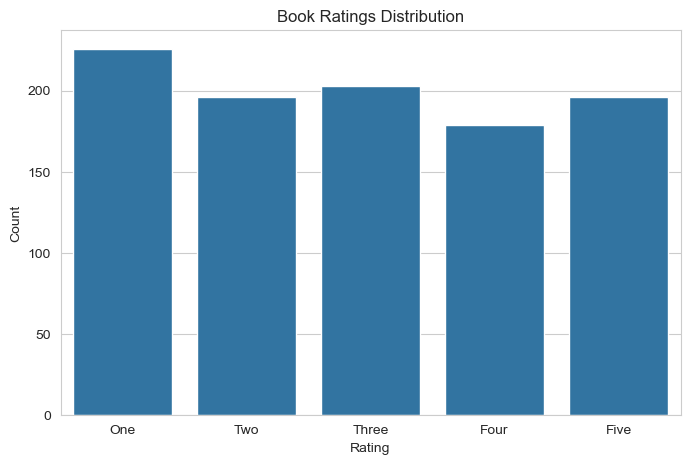

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Rating",
    data=df,
    order=["One","Two","Three","Four","Five"]
)

plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

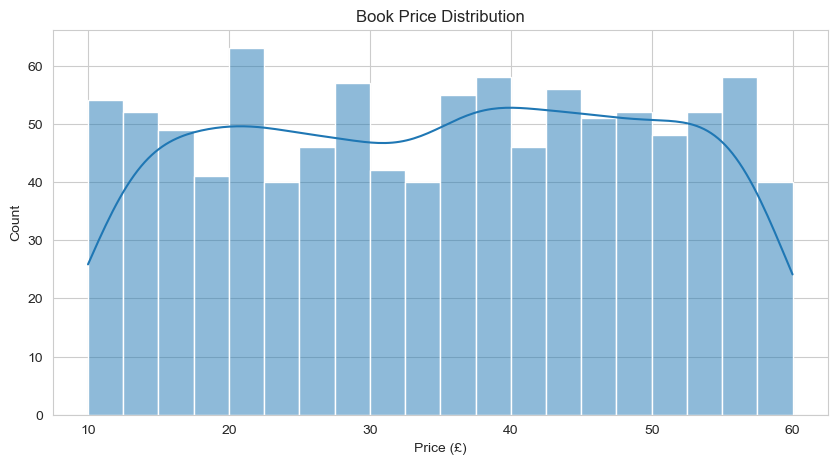

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price"], bins=20, kde=True)

plt.title("Book Price Distribution")
plt.xlabel("Price (£)")

plt.show()

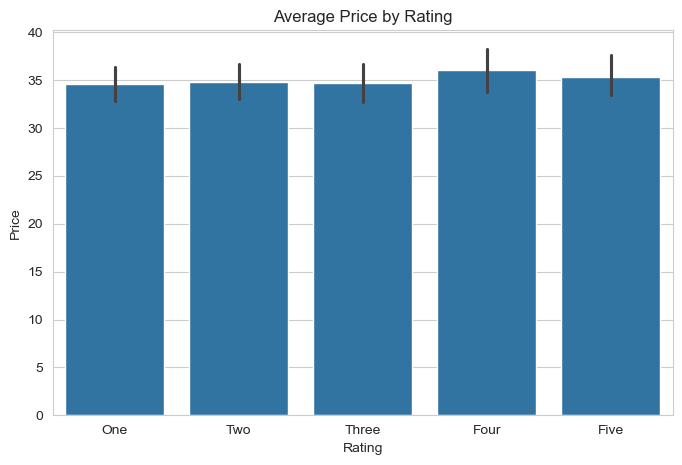

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Rating",
    y="Price",
    data=df,
    order=["One","Two","Three","Four","Five"]
)

plt.title("Average Price by Rating")

plt.show()

In [22]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Number"] = df["Rating"].map(rating_map)

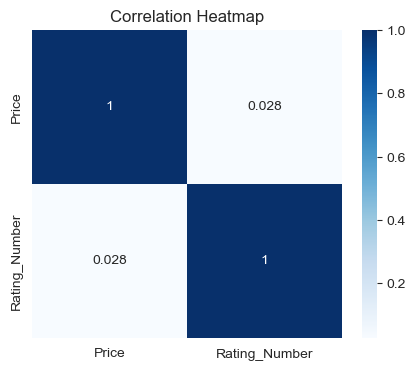

In [23]:
corr = df[["Price", "Rating_Number"]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

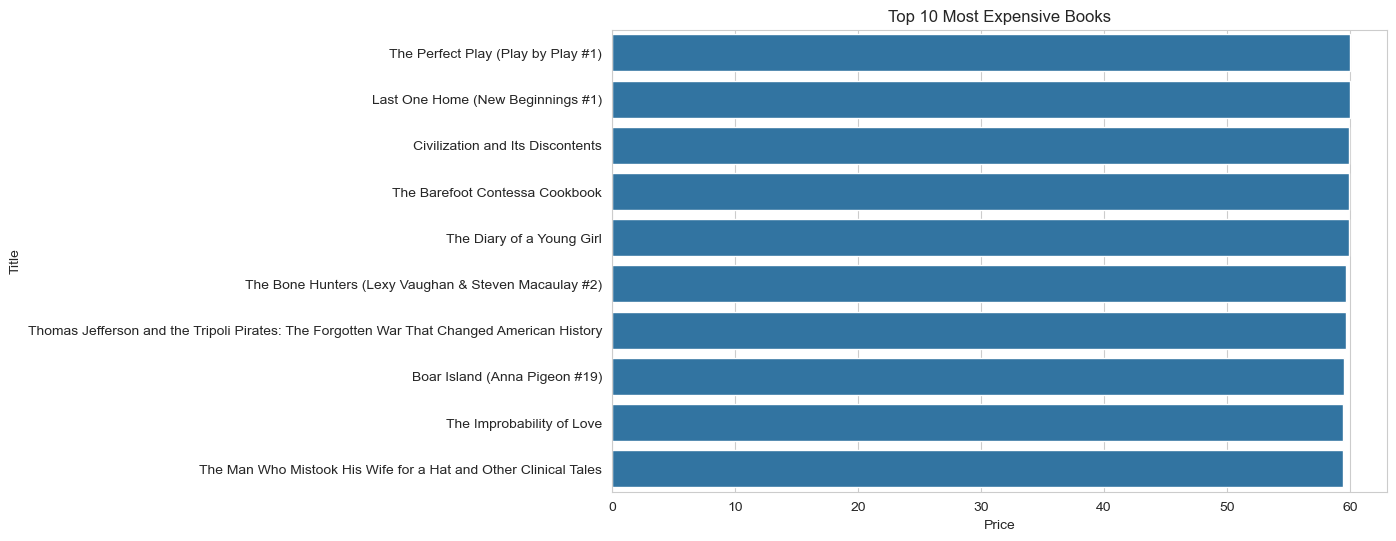

In [24]:
top_books = df.nlargest(10, "Price")

plt.figure(figsize=(10,6))

sns.barplot(
    x="Price",
    y="Title",
    data=top_books
)

plt.title("Top 10 Most Expensive Books")

plt.show()

Price vs Rating Scatter Plot
↓
Rating Distribution Chart
↓
Price Distribution Chart
↓
# Insights
- Most books have Three-Star ratings.
- Book prices range from low to high with some variation.
- Higher-rated books are not always the most expensive.
- The dataset contains 1,000 books with no major issues after cleaning.

# Conclusion

This project performed Exploratory Data Analysis (EDA) on a dataset of 1,000 books scraped from the Books to Scrape website. The dataset was cleaned, explored, and visualized using Python libraries such as Pandas, Matplotlib, and Seaborn. The analysis showed the distribution of book ratings, pricing trends, and the relationship between ratings and prices. This project demonstrates data cleaning, visualization, and analytical skills.

# References

- Books to Scrape: https://books.toscrape.com/
- Pandas Documentation: https://pandas.pydata.org/
- Matplotlib Documentation: https://matplotlib.org/
- Seaborn Documentation: https://seaborn.pydata.org/